<a href="https://colab.research.google.com/github/ArteagaCE/EA3/blob/main/TPN1_EA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El presente cuaderno tiene como propósito realizar un análisis de los caraterísticas de interés de un acople:

*   Frecuencia de resonancia (fo)
*   Ancho de banda (BW)
*   Factor de calidad descargado (Qd)
*   Factor de calidad cargado (Qc)
*   ROE
*   Zo
*   Rp
*   L
*   C
*   C1
*   C2
*   C3
*   C4










In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.optimize import fsolve
from scipy.optimize import least_squares

# 1. Definimos la frecuencia de resonancia y el ancho de banda especificado:
f_res = 16 *1e6
BW = f_res * 0.1     # Definición del ancho de banda BW en MHz
print(f"Frecuencia de resonancia: {f_res} Hz")
print()
print(f"Ancho de banda: {BW} Hz")
print()

# 2. PARÁMETROS FÍSICOS DEL INDUCTOR

# Realizamos un arreglo con los valores posibles de los diametros de cobre es-
# maltados para su posterior analisis. Actualmente se cuanta con alambre de cobre
# esmaltado de 0,18 cm y de 0,2 de diámetro
Diametros_cm = np.zeros(4)
for i in range(len(Diametros_cm)):
    Diametros_cm [i] = 0.19+(i*0.005)
print()
print(f"Diametros: {Diametros_cm} cm")
print()

#Para facilitar la construcción de la bobina se utilizará una separación de bo-
#vinas del mismo tamaño que los conductores:
Se_cm = np.zeros(len(Diametros_cm))
for i in range(len(Se_cm)):
    Se_cm [i] = Diametros_cm[i]
print(f"Separación entre espiras: {Se_cm} cm")
print()

#Para realizar la bobina se propone usar algún objeto lo más cilíndrico posible
#para ello se pide al usuario que ingrese el valor del diametro a usar como gía
#para la elaboración de la bovina:

Do_cm = float(input("Ingrese el diámetro de la bobina de guía (1.5 - 3 cm): "))
print()

#Creamos un vector con los posibles diametros totales
Dtotal_cm = np.zeros(len(Diametros_cm))
for i in range(len(Dtotal_cm)):
  Dtotal_cm[i]= Do_cm + 2* Diametros_cm [i]
print(f"Diametro total de la bobina: {Dtotal_cm} cm")
print()

#Sabiendo que se desea diseñar una bobina lo más cercana a una bobina cuadrada
#se define a la relación largo/diametro con una variación entre 1 y 2:

RelacionLD = np.zeros(11)
for i in range(11):
  RelacionLD[i] = 1 + i*0.1
print(f"Relaciones Diamtro vs Largo: {RelacionLD} ")
print()

#Como vamos a tener 2 diámetros de cable posibles y con cada diametro vamos
#a tener 11 opciones de largos para cada diametro. Entonces tendremos las posibles
# largos:

# RelacionLD = L/D
# Largo = RelacionLD*D
Largo_cm = np.zeros((len(RelacionLD),len(Dtotal_cm)))  #Array con los posibles largos
for i in range(len(RelacionLD)):
  for j in range(len(Dtotal_cm)):
    Largo_cm [i,j] = Dtotal_cm[j] * RelacionLD[i]

#Asi mismo tendremos un numero de espiras dado por:
# Numero de espiras = largo / (DiametroTotal + Se)
# Donde en este caso Se = Diametro total.
N = np.zeros((len(RelacionLD),len(Dtotal_cm)))  #Array con número de espiras posibles
for i in range(len(RelacionLD)):
  for j in range(len(Dtotal_cm)):
    N [i,j] = Largo_cm[i,j]/(2*Diametros_cm[j])

# Realizamos las tablas

# Creamos etiquetas para las filas y columnas
# Usamos los valores reales para que la tabla sea fácil de leer
filas_relacion = [f"L/D={r:.1f}" for r in RelacionLD]
columnas_diams = [f"D_cu={d:.3f}cm" for d in Diametros_cm]

# Convertimos la matriz de Largos en una Tabla (DataFrame)
df_largos = pd.DataFrame(Largo_cm, index=filas_relacion, columns=columnas_diams)

# Convertimos la matriz de Espiras (N) en una Tabla
df_espiras = pd.DataFrame(N, index=filas_relacion, columns=columnas_diams)

# Mostrar las tablas
print("TABLA DE LARGOS DE BOBINA (cm)")
display(df_largos)

print("\nTABLA DE NÚMERO DE ESPIRAS (N)")
display(df_espiras)

Frecuencia de resonancia: 16000000.0 Hz

Ancho de banda: 1600000.0 Hz


Diametros: [0.19  0.195 0.2   0.205] cm

Separación entre espiras: [0.19  0.195 0.2   0.205] cm

Ingrese el diámetro de la bobina de guía (1.5 - 3 cm): 2.36

Diametro total de la bobina: [2.74 2.75 2.76 2.77] cm

Relaciones Diamtro vs Largo: [1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ] 

TABLA DE LARGOS DE BOBINA (cm)


,D_cu=0.190cm,D_cu=0.195cm,D_cu=0.200cm,D_cu=0.205cm
L/D=1.0,2.740,2.750,2.760,2.770
L/D=1.1,3.014,3.025,3.036,3.047
L/D=1.2,3.288,3.300,3.312,3.324
L/D=1.3,3.562,3.575,3.588,3.601
L/D=1.4,3.836,3.850,3.864,3.878
L/D=1.5,4.110,4.125,4.140,4.155
L/D=1.6,4.384,4.400,4.416,4.432
L/D=1.7,4.658,4.675,4.692,4.709
L/D=1.8,4.932,4.950,4.968,4.986
L/D=1.9,5.206,5.225,5.244,5.263



TABLA DE NÚMERO DE ESPIRAS (N)


,D_cu=0.190cm,D_cu=0.195cm,D_cu=0.200cm,D_cu=0.205cm
L/D=1.0,7.210526,7.051282,6.90,6.756098
L/D=1.1,7.931579,7.756410,7.59,7.431707
L/D=1.2,8.652632,8.461538,8.28,8.107317
L/D=1.3,9.373684,9.166667,8.97,8.782927
L/D=1.4,10.094737,9.871795,9.66,9.458537
L/D=1.5,10.815789,10.576923,10.35,10.134146
L/D=1.6,11.536842,11.282051,11.04,10.809756
L/D=1.7,12.257895,11.987179,11.73,11.485366
L/D=1.8,12.978947,12.692308,12.42,12.160976
L/D=1.9,13.700000,13.397436,13.11,12.836585


Ahora ya tenemos las posibles características constructivas físicas de la bovina(Diametro del cobre, diametro de la bobina total, separación entre espiras, largo de la bovina y relación L/D).
Ahora analizamos las características físicas como la inductancia, el factor k, la resistencia de pérdida del mismo, el factor de mérito descargado y cargado.

In [ ]:
# 3. Calculamos las inductancias resultantes para cada caso

#(Fórmula de Wheeler para bobinas de una capa)
# L (uH) = (0.394 * r^2 * N^2) / (9*r + 10*l) -> r y l en cm
r_cm = np.zeros(len(RelacionLD))
for i in range(len(Dtotal_cm)):
  r_cm [i] = (Dtotal_cm[i] / 2)
  inductancia_uh = np.zeros((len(RelacionLD),len(Dtotal_cm)))
  for i in range(len(RelacionLD)):
    for j in range(len(Dtotal_cm)):
      inductancia_uh [i,j] = (0.394 * (r_cm[j]**2) * (N[i,j]**2)) / (9 * r_cm[j] + 10 * Largo_cm[i,j])

df_inductancias = pd.DataFrame(inductancia_uh, index=filas_relacion, columns=columnas_diams)
print("TABLA DE INDUCTANCIAS DE BOBINA (uH)")
display(df_inductancias)

TABLA DE INDUCTANCIAS DE BOBINA (uH)


,D_cu=0.190cm,D_cu=0.195cm,D_cu=0.200cm,D_cu=0.205cm
L/D=1.0,0.967727,0.928832,0.892638,0.858895
L/D=1.1,1.095404,1.051378,1.010409,0.972213
L/D=1.2,1.224614,1.175394,1.129593,1.086892
L/D=1.3,1.355094,1.300630,1.249949,1.202698
L/D=1.4,1.486637,1.426887,1.371285,1.319448
L/D=1.5,1.619081,1.554007,1.493452,1.436997
L/D=1.6,1.752293,1.681865,1.616328,1.555228
L/D=1.7,1.886167,1.810358,1.739814,1.674045
L/D=1.8,2.020613,1.939401,1.863829,1.793372
L/D=1.9,2.155560,2.068924,1.988304,1.913142


In [ ]:
# --- 4. CÁLCULO DE FACTORES DE MÉRITO Y RESISTENCIA DE PÉRDIDAS ---

# 4.1 Q Cargado (Basado en el BW solicitado por el usuario)
# Como BW es el 10% de f_res, QL será constante para toda la matriz
QL_val = f_res / BW
print(f"El factor de mérito cargado es: {QL_val}")
print()

# Q Descargado (Estimación por geometría y frecuencia)
Q_descargado = np.zeros((len(RelacionLD), len(Dtotal_cm)))
for i in range(len(RelacionLD)):
    for j in range(len(Dtotal_cm)):
        # Qdescargado = 8550 * ((Diámetro(cm)*Largo)/(120*Largo+450)) * sqrt(f_MHz)
        Q_descargado[i, j] = 8550 * ((Dtotal_cm[j]*Largo_cm[i,j])/(120*Largo_cm[i,j]+450)) * np.sqrt(f_res*1e-6)

# 4.2 Resistencia de Pérdidas RP
RP = np.zeros((len(RelacionLD), len(Dtotal_cm)))
for i in range(len(RelacionLD)):
    for j in range(len(Dtotal_cm)):
        # XL = 2 * pi * f * L
        XL = 2 * np.pi * f_res * (inductancia_uh[i, j] * 1e-6)
        RP[i, j] = Q_descargado[i, j] * XL

# --- 6. GENERACIÓN DE TABLAS FINALES ---

df_Qdescargado = pd.DataFrame(Q_descargado, index=filas_relacion, columns=columnas_diams)
df_RP = pd.DataFrame(RP, index=filas_relacion, columns=columnas_diams)


print("\nTABLA DE FACTOR DE MÉRITO DESCARGADO (Qo)")
display(df_Qdescargado)

print("\nTABLA DE RESISTENCIA DE PÉRDIDAS RP (Ohms)")
display(df_RP)

El factor de mérito cargado es: 10.0


TABLA DE FACTOR DE MÉRITO DESCARGADO (Qo)


,D_cu=0.190cm,D_cu=0.195cm,D_cu=0.200cm,D_cu=0.205cm
L/D=1.0,329.686595,331.586538,333.489401,335.395169
L/D=1.1,347.964607,349.940037,351.918302,353.899389
L/D=1.2,364.819437,366.861702,368.906712,370.954453
L/D=1.3,380.411078,382.512799,384.617171,386.724180
L/D=1.4,394.876404,397.031250,399.188652,401.348597
L/D=1.5,408.333206,410.535714,412.740684,414.948102
L/D=1.6,420.883403,423.128834,425.376635,427.626791
L/D=1.7,432.615628,434.899852,437.186354,439.475121
L/D=1.8,443.607326,445.926724,448.248314,450.572081
L/D=1.9,453.926463,456.277855,458.631354,460.986947



TABLA DE RESISTENCIA DE PÉRDIDAS RP (Ohms)


,D_cu=0.190cm,D_cu=0.195cm,D_cu=0.200cm,D_cu=0.205cm
L/D=1.0,32074.054540,30962.344448,29926.599966,28959.861161
L/D=1.1,38318.572415,36987.268024,35746.939985,34589.251234
L/D=1.2,44913.520055,43349.677766,41892.709471,40532.819233
L/D=1.3,51822.980608,50014.919695,48330.431212,46758.186503
L/D=1.4,59015.501588,56952.656087,55030.806210,53237.023712
L/D=1.5,66463.496090,64136.284928,61968.150127,59944.503156
L/D=1.6,74142.714318,71542.427948,69119.896716,66858.816574
L/D=1.7,82031.785330,79150.486990,76466.167814,73960.757865
L/D=1.8,90111.823487,86942.263209,83989.404435,81233.365276
L/D=1.9,98366.092109,94901.631783,91674.051772,88661.616036


Finalizando así el análisis del diseño del inductor.
Ahora se propone calcular la capacitancia total necesaria para obtener la frecuencia de resonancia deseada según el valor de inductancia obtenido anteriormente.

In [ ]:
#Partimos de un valor de inductacia dada por las tablas anteriores:

#Calculamos el valor de la capacitancia fianl:
#C = 1/(((2*pi*fo)^2)*L))
C_total = np.zeros((len(RelacionLD), len(Dtotal_cm)))
for i in range(len(RelacionLD)):
  for j in range(len(Dtotal_cm)):
    C_total[i,j] = 1/(((2*np.pi*f_res)**2)*inductancia_uh[i,j]*(1e-6))

df_Ctotal = pd.DataFrame(C_total, index=filas_relacion, columns=columnas_diams)

print("\nTABLA DE CAPACITANCIA TOTAL (Ct)")
display(df_Ctotal)







TABLA DE CAPACITANCIA TOTAL (Ct)


,D_cu=0.190cm,D_cu=0.195cm,D_cu=0.200cm,D_cu=0.205cm
L/D=1.0,1.022463e-10,1.065279e-10,1.108472e-10,1.152021e-10
L/D=1.1,9.032873e-11,9.411125e-11,9.792715e-11,1.017745e-10
L/D=1.2,8.079808e-11,8.418150e-11,8.759479e-11,9.103616e-11
L/D=1.3,7.301817e-11,7.607580e-11,7.916043e-11,8.227044e-11
L/D=1.4,6.655723e-11,6.934431e-11,7.215600e-11,7.499082e-11
L/D=1.5,6.111273e-11,6.367182e-11,6.625351e-11,6.885644e-11
L/D=1.6,5.646684e-11,5.883139e-11,6.121681e-11,6.362186e-11
L/D=1.7,5.245902e-11,5.465574e-11,5.687186e-11,5.910621e-11
L/D=1.8,4.896853e-11,5.101909e-11,5.308775e-11,5.517343e-11
L/D=1.9,4.590291e-11,4.782510e-11,4.976425e-11,5.171936e-11


Ahora graficamos los parametros de interés:

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\O'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_20417/2789356924.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Inductancia ($\mu H$)')
/tmp/ipykernel_20417/2789356924.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Inductancia ($\mu H$)')
/tmp/ipykernel_20417/2789356924.py:37: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$R_P$ ($\Omega$)')


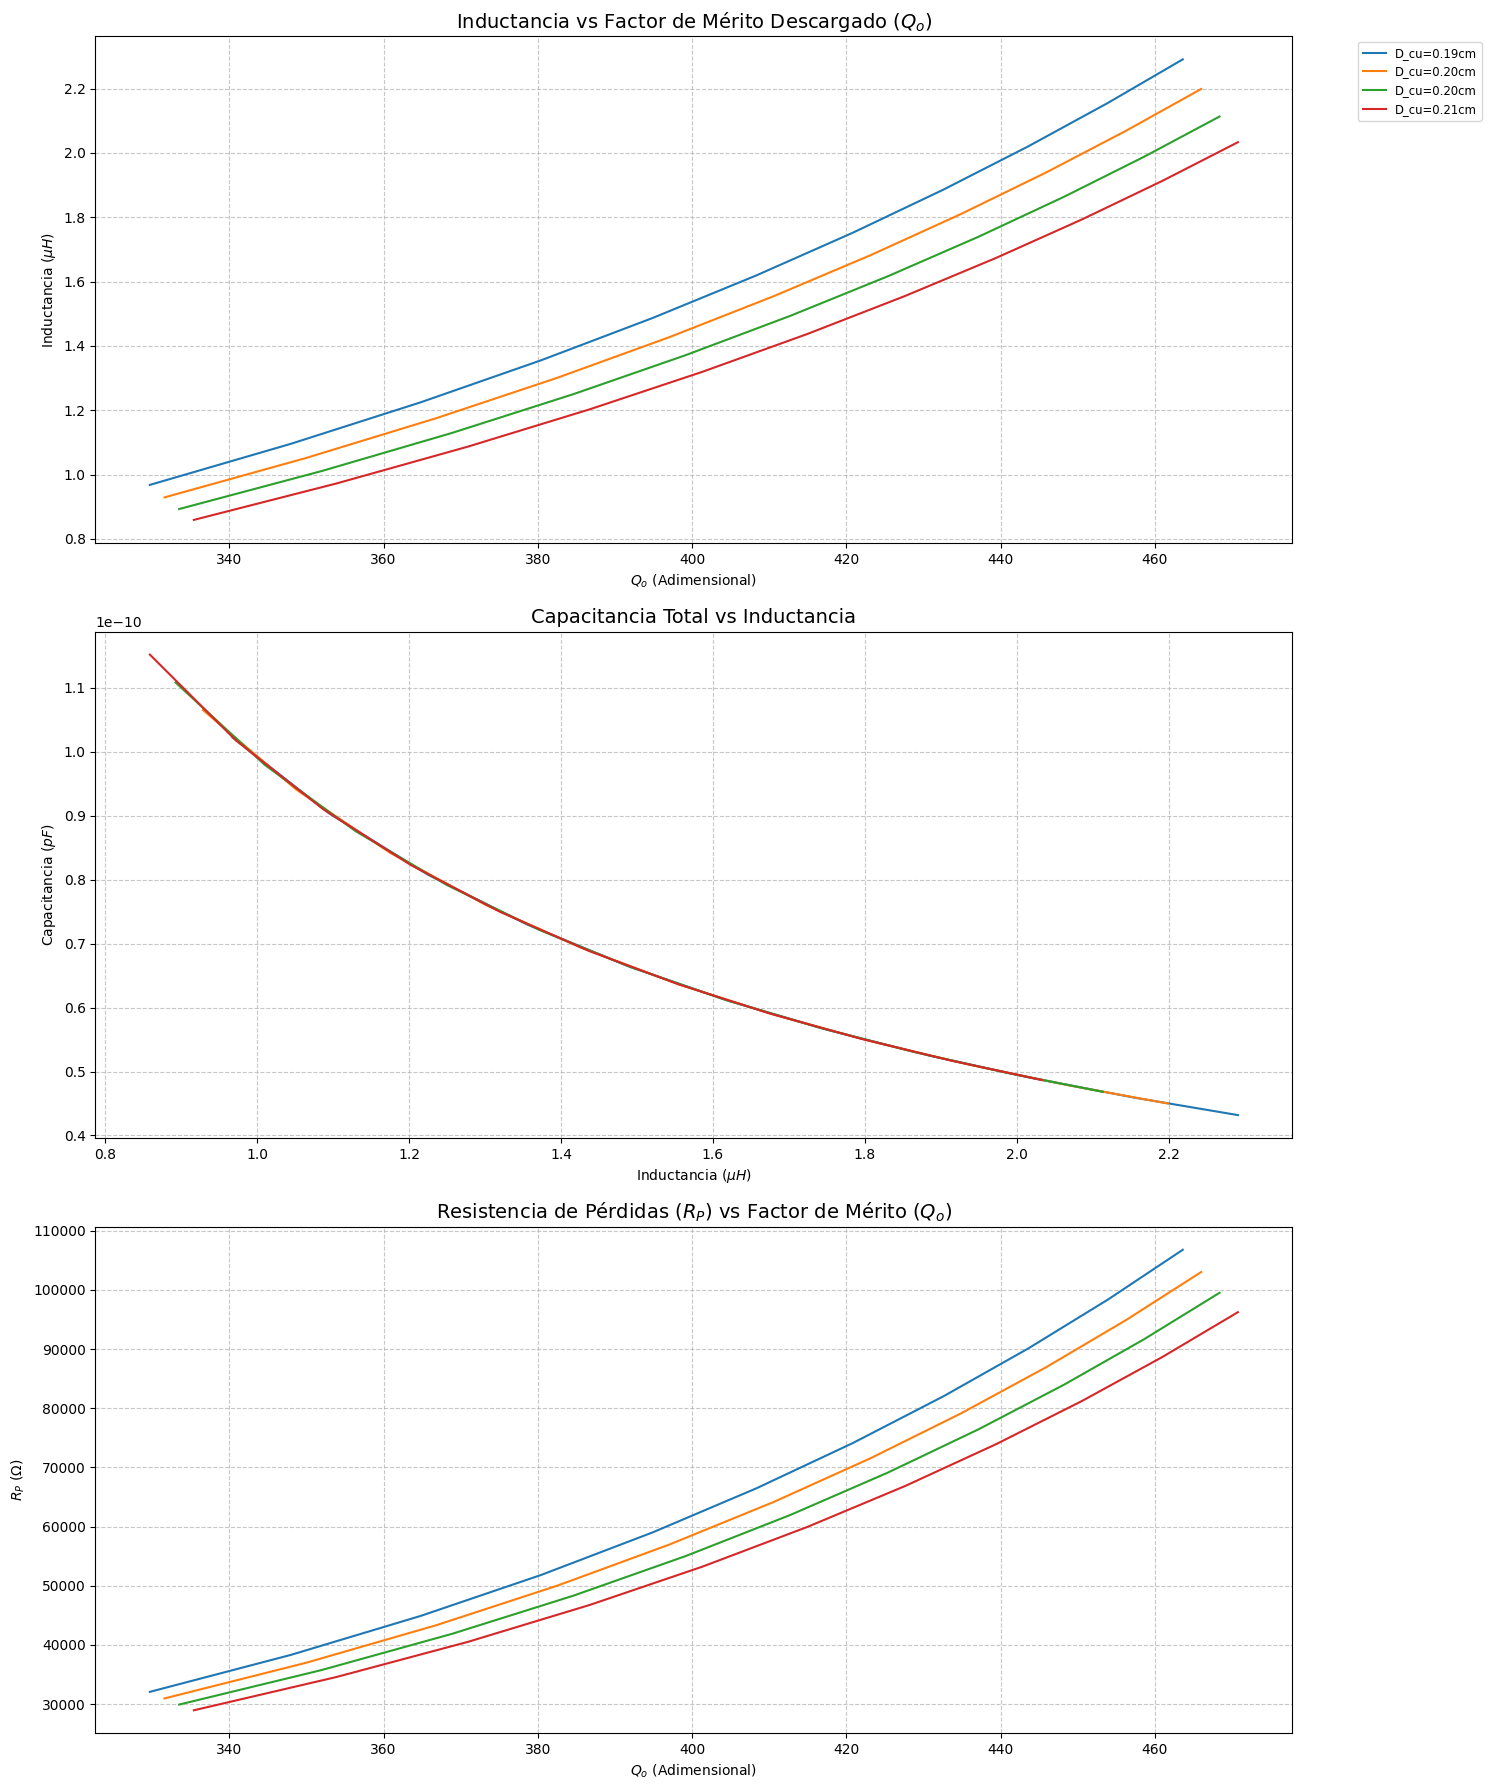

In [ ]:
import matplotlib.pyplot as plt

# Configuramos el tamaño de las figuras para que sean legibles
plt.figure(figsize=(15, 18))

# 1. Gráfico: Inductancia vs Q Descargado
plt.subplot(3, 1, 1)
for j in range(len(Diametros_cm)):
    # Graficamos para cada diámetro (columna j)
    plt.plot(Q_descargado[:, j], inductancia_uh[:, j], label=f'D_cu={Diametros_cm[j]:.2f}cm')

plt.title('Inductancia vs Factor de Mérito Descargado ($Q_o$)', fontsize=14)
plt.xlabel('$Q_o$ (Adimensional)')
plt.ylabel('Inductancia ($\mu H$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# 2. Gráfico: Capacitancia Total vs Inductancia
plt.subplot(3, 1, 2)
for j in range(len(Diametros_cm)):
    plt.plot(inductancia_uh[:, j], C_total[:, j], label=f'D_cu={Diametros_cm[j]:.2f}cm')

plt.title('Capacitancia Total vs Inductancia', fontsize=14)
plt.xlabel('Inductancia ($\mu H$)')
plt.ylabel('Capacitancia ($pF$)')
plt.grid(True, linestyle='--', alpha=0.7)
# (Opcional) No repetimos la leyenda si es la misma para ahorrar espacio
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# 3. Gráfico: Resistencia de Pérdidas (RP) vs Q Descargado
plt.subplot(3, 1, 3)
for j in range(len(Diametros_cm)):
    plt.plot(Q_descargado[:, j], RP[:, j], label=f'D_cu={Diametros_cm[j]:.2f}cm')

plt.title('Resistencia de Pérdidas ($R_P$) vs Factor de Mérito ($Q_o$)', fontsize=14)
plt.xlabel('$Q_o$ (Adimensional)')
plt.ylabel('$R_P$ ($\Omega$)')
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustar diseño para que no se solapen
plt.tight_layout()
plt.show()

Para asegurar un ancho de banda del 10% de la frecuencia de resonancia ahora debemos encontrar un RT = (Rp//Rg'//Rl').
Las posibles RT(Dependiendo de cada caso) son:

In [ ]:
#Utilizando la fórmula:
# Qload = Rt/Xl
#Entonces:
# RT = Qload*Xl

R_total = np.zeros((len(RelacionLD), len(Dtotal_cm)))
for i in range(len(RelacionLD)):
  for j in range(len(Dtotal_cm)):
    # XL = 2 * pi * f * L
    XL = 2 * np.pi * f_res * (inductancia_uh[i, j] * 1e-6)
    R_total[i,j] = QL_val*XL

df_R_total = pd.DataFrame(R_total, index=filas_relacion, columns=columnas_diams)

print("\nTABLA DE RESISTENCIA TOTAL (RT)")
display(df_R_total)


TABLA DE RESISTENCIA TOTAL (RT)


,D_cu=0.190cm,D_cu=0.195cm,D_cu=0.200cm,D_cu=0.205cm
L/D=1.0,972.864989,933.763614,897.377844,863.454929
L/D=1.1,1101.220402,1056.960168,1015.773824,977.375273
L/D=1.2,1231.116422,1181.635410,1135.590872,1092.662965
L/D=1.3,1362.288946,1307.535849,1256.585376,1209.083602
L/D=1.4,1494.530972,1434.462806,1378.566396,1326.453464
L/D=1.5,1627.677962,1562.258354,1501.382162,1444.626516
L/D=1.6,1761.597483,1690.795383,1624.910516,1563.485218
L/D=1.7,1896.181738,1819.970430,1749.052026,1682.933898
L/D=1.8,2031.342097,1949.698426,1873.724939,1802.893892
L/D=1.9,2167.005015,2079.908782,1998.861415,1923.299926


Utilizando el criterio de adaptación de la entrada del circuito se tiene que:

$$
R_g' = 2R_T
$$

$$
R_p//R_L' = 2R_T
$$

Mientras que las ecuaciones que relacionan los capacitores con las resistencias del circuito son:
$$
R_g' = \left(1+\frac{C_2}{C_1}\right)^2 R_g
$$

$$
R_L' = \left(1+\frac{C_4}{C_3}\right)^2 R_l
$$

Además de que la disposición de capacitores en el circuito nos permite escribir:

$$
\begin{cases}
\frac{C_1 C_2}{C_1 + C_2} = \frac{C}{2} \\
\frac{C_3 C_4}{C_3 + C_4} = \frac{C}{2}
\end{cases}
$$

Por lo que si sabemos que: $R_g = 50 \Omega$ y $R_L = 1000 \Omega$

Entonces:

In [ ]:

#Planteo las 4 ecuaciones para determinar los Capacitores C1, C2, C3 Y C4
#Rl_p = ((1+(C4/C3)**2))*Rl
#Rg_p = ((1+(C2/C1))**2)*Rg
#(C1*C2)/(C1+C2)=CT/2
#(C3*C4)/(C3+C4)=CT/2



# 1. DEFINICIÓN DE VARIABLES
fila = 3
columna = 2
inductancia_uh_final = inductancia_uh[fila,columna]
Rt = R_total[fila,columna]
Ct = C_total[fila,columna]
Rp = RP[fila,columna]

# Valores de impedancia de fuente y carga
Rl = 1000
Rg = 50

# 2. DEFINICIÓN DEL SISTEMA DE ECUACIONES
def sistema_acople(c):
    # c = [C1, C2, C3, C4]
    C1, C2, C3, C4 = c

    # Ecuación 1: Transformación de Rg a 2*Rt
    # Rg' = Rg * (1 + C2/C1)^2
    eq1 = Rg * (1 + (C2/C1))**2 - (2 * Rt)

    # Ecuación 2: Transformación de Rl en paralelo con Rp a 2*Rt
    # Rl' = Rl * (1 + C4/C3)^2
    Rlp = Rl * (1 + (C4/C3))**2
    paralelo_carga = (Rp * Rlp) / (Rp + Rlp)
    eq2 = paralelo_carga - (2 * Rt)

    # Ecuación 3: Rama 1 (C1 serie C2) debe ser Ct/2
    eq3 = (C1 * C2) / (C1 + C2) - (Ct / 2)

    # Ecuación 4: Rama 2 (C3 serie C4) debe ser Ct/2
    eq4 = (C3 * C4) / (C3 + C4) - (Ct / 2)

    return [eq1, eq2, eq3, eq4]

# 3. RESOLUCIÓN
# Estimación inicial: se asume que los capacitores shunt son mayores que los serie
semilla = [Ct, Ct*10, Ct, Ct*2]
solucion = fsolve(sistema_acople, semilla)

C1_f, C2_f, C3_f, C4_f = solucion

# 4. IMPRESIÓN DE RESULTADOS
print(f"--- RESULTADOS DEL ACOPLE (Valores Ideales) ---")
print(f"Frecuencia de Resonancia: {f_res/1e6:.2f} MHz")
print(f"Inductancia final (If): {inductancia_uh_final:.4f} uH")
print(f"Resistencia total (Rt): {Rt:.4f} Ohms")
print(f"Resistencia de pérdida final (Rp): {Rp*1e-3:.4f} kOhms\n")

print(f"Capacidad Total (Ct): {Ct*1e12:.4f} pF")
print(f"C1: {C1_f*1e12:.4f} pF")
print(f"C2: {C2_f*1e12:.4f} pF")
print(f"C3: {C3_f*1e12:.4f} pF")
print(f"C4: {C4_f*1e12:.4f} pF\n")

# Verificación de resonancia
Ct_final = ((C1_f * C2_f) / (C1_f + C2_f)) + ((C3_f * C4_f) / (C3_f + C4_f))
f_res = 1 / (2 * np.pi * np.sqrt(inductancia_uh_final*1e-6* Ct_final))

print(f"--- VERIFICACIÓN ---")
print(f"Ct resultante: {Ct_final*1e12:.4f} pF (Error: {abs(Ct-Ct_final):.2e})")
print(f"Frecuencia resultante: {f_res/1e6:.4f} MHz")

--- RESULTADOS DEL ACOPLE (Valores Ideales) ---
Frecuencia de Resonancia: 16.00 MHz
Inductancia final (If): 1.2499 uH
Resistencia total (Rt): 1256.5854 Ohms
Resistencia de pérdida final (Rp): 48.3304 kOhms

Capacidad Total (Ct): 79.1604 pF
C1: 46.0798 pF
C2: 280.6106 pF
C3: 102.5863 pF
C4: 64.4444 pF

--- VERIFICACIÓN ---
Ct resultante: 79.1604 pF (Error: 3.28e-21)
Frecuencia resultante: 16.0000 MHz


In [ ]:
import numpy as np

# 1. VALORES COMERCIALES DISPONIBLES (en pF)
comerciales = [10, 15, 22, 33, 47, 100, 120, 130, 150, 180, 220, 330, 470, 560, 680, 750, 820, 1000]

# 2. VALORES IDEALES A ALCANZAR (en pF)
ideales = {
    "C1":C1_f*1e12,
    "C2":C2_f*1e12,
    "C3":C3_f*1e12,
    "C4":C4_f*1e12
}

def encontrar_mejor_combinacion(objetivo):
    mejor_valor = 0
    mejor_error = float('inf')
    mejor_descripcion = ""

    # Opción A: Un solo capacitor
    for c in comerciales:
        error = abs(c - objetivo)
        if error < mejor_error:
            mejor_error = error
            mejor_valor = c
            mejor_descripcion = f"{c} pF (Simple)"

    # Opción B: Dos en Paralelo (C = Ca + Cb)
    for i in range(len(comerciales)):
        for j in range(i, len(comerciales)):
            suma = comerciales[i] + comerciales[j]
            error = abs(suma - objetivo)
            if error < mejor_error:
                mejor_error = error
                mejor_valor = suma
                mejor_descripcion = f"{comerciales[i]} pF || {comerciales[j]} pF"

    # Opción C: Dos en Serie (C = (Ca * Cb) / (Ca + Cb))
    for i in range(len(comerciales)):
        for j in range(i, len(comerciales)):
            serie = (comerciales[i] * comerciales[j]) / (comerciales[i] + comerciales[j])
            error = abs(serie - objetivo)
            if error < mejor_error:
                mejor_error = error
                mejor_valor = serie
                mejor_descripcion = f"{comerciales[i]} pF serie {comerciales[j]} pF"

    return mejor_valor, mejor_descripcion

# 3. EJECUCIÓN Y RESULTADOS
print(f"{'Cap.':<5} | {'Ideal (pF)':<12} | {'Comercial (pF)':<15} | {'Configuración'}")
print("-" * 65)

capacitores_finales = {}
for nombre, valor_ideal in ideales.items():
    valor_com, desc = encontrar_mejor_combinacion(valor_ideal)
    capacitores_finales[nombre] = valor_com
    print(f"{nombre:<5} | {valor_ideal:<12.4f} | {valor_com:<15.4f} | {desc}")

# 4. VERIFICACIÓN DE IMPACTO EN CAPACIDAD TOTAL
CT_ideal = ((ideales["C1"]*ideales["C2"])/(ideales["C1"]+ideales["C2"])) + ((ideales["C3"]*ideales["C4"])/(ideales["C3"]+ideales["C4"]))
CT_comercial = ((capacitores_finales["C1"]*capacitores_finales["C2"])/(capacitores_finales["C1"]+capacitores_finales["C2"])) + ((capacitores_finales["C3"]*capacitores_finales["C4"])/(capacitores_finales["C3"]+capacitores_finales["C4"]))

print("\n--- ANÁLISIS DE DESVIACIÓN ---")
print(f"Capacidad Total Ideal: {CT_ideal:.4f} pF")
print(f"Capacidad Total con Comerciales: {CT_comercial:.4f} pF")
print(f"Error en CT: {abs(CT_ideal - CT_comercial):.4f} pF ({abs(1 - CT_comercial/CT_ideal)*100:.2f}%)")

Cap.  | Ideal (pF)   | Comercial (pF)  | Configuración
-----------------------------------------------------------------
C1    | 46.0798      | 47.0000         | 47 pF (Simple)
C2    | 280.6106     | 280.0000        | 100 pF || 180 pF
C3    | 102.5863     | 103.1250        | 150 pF serie 330 pF
C4    | 64.4444      | 64.2857         | 100 pF serie 180 pF

--- ANÁLISIS DE DESVIACIÓN ---
Capacidad Total Ideal: 79.1604 pF
Capacidad Total con Comerciales: 79.8446 pF
Error en CT: 0.6842 pF (0.86%)
